# End-to-End CNN Image Classification Project

In [1]:
import tensorflow as tf
import keras
from keras import layers
from keras.models import Sequential
import matplotlib.pyplot as plt
import numpy as np
import os
import random
from PIL import Image
from sklearn.metrics import classification_report
import shutil
from google.colab import drive
import zipfile

### Data Preparation

In [2]:
drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/FruitinAmazon.zip'
extracted_base_path = '/content/fruit_dataset'


Mounted at /content/drive


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:

os.makedirs(extracted_base_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_base_path)

content_dirs = [d for d in os.listdir(extracted_base_path) if os.path.isdir(os.path.join(extracted_base_path, d))]
if len(content_dirs) == 1:
    data_dir = os.path.join(extracted_base_path, content_dirs[0])
elif len(content_dirs) > 1:
    data_dir = extracted_base_path
else:
    data_dir = extracted_base_path

print(f"Data directory set to: {data_dir}")

Data directory set to: /content/fruit_dataset/FruitinAmazon


### Task 1: Data Understanding and Visualization

In [5]:
class_names = sorted([name for name in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, name))])

plt.figure(figsize=(10, 5))
num_classes = len(class_names)

for i, class_name in enumerate(class_names):
    class_path = os.path.join(data_dir, class_name)
    files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
    if not files:
        continue
    random_image_name = random.choice(files)
    random_image_path = os.path.join(class_path, random_image_name)
    img = Image.open(random_image_path)

    plt.subplot(2, (num_classes + 1) // 2, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

### Task 1 (Part 2): Corrupted Image Detection

In [6]:
corrupted_images = []

for root, dirs, files in os.walk(data_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            file_path = os.path.join(root, file)
            try:
                img = Image.open(file_path)
                img.verify()
            except (IOError, SyntaxError) as e:
                corrupted_images.append(file_path)

if corrupted_images:
    for img_path in corrupted_images:
        os.remove(img_path)
        print(f"Removed corrupted image: {img_path}")
else:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


### Task 2: Loading and Preprocessing Image Data

In [7]:
image_size = (128, 128)
batch_size = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='int'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='int'
)

class_names = train_ds.class_names
num_classes = len(class_names)

normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

Found 120 files belonging to 2 classes.
Using 96 files for training.
Found 120 files belonging to 2 classes.
Using 24 files for validation.


### Task 3: Implement a CNN

In [8]:
model = Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(image_size[0], image_size[1], 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Task 4: Compile the Model

In [9]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

### Task 5: Train the Model

In [10]:
epochs = 250

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

checkpoint_filepath = 'best_model.h5'
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=[early_stopping, model_checkpoint_callback]
)

Epoch 1/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.3970 - loss: 1.1803

6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 382ms/step - accuracy: 0.5000 - loss: 1.0704 - val_accuracy: 0.9167 - val_loss: 0.3345
Epoch 2/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 321ms/step - accuracy: 0.7083 - loss: 0.5821 - val_accuracy: 0.9167 - val_loss: 0.5405
Epoch 3/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 320ms/step - accuracy: 0.7188 - loss: 0.5761 - val_accuracy: 0.9167 - val_loss: 0.3566
Epoch 4/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 326ms/step - accuracy: 0.7604 - loss: 0.4892 - val_accuracy: 0.9167 - val_loss: 0.3529
Epoch 5/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 484ms/step - accuracy: 0.7396 - loss: 0.3967 - val_accuracy: 0.9167 - val_loss: 0.4022
Epoch 6/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 538ms/step - accuracy: 0.9062 - loss: 0.2901 - val_accuracy: 0.9167 - val_loss: 0.3578
Epoch 7/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 309ms/step - accuracy: 0.9167 - loss: 0.2421 - val_accuracy: 0.8333 - val_loss: 0.4964
Epoch 8/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 300ms/step - accuracy: 0.9792 - loss: 0.1416 - val_accuracy: 0.9167 - val_loss: 0.4

### Visualization

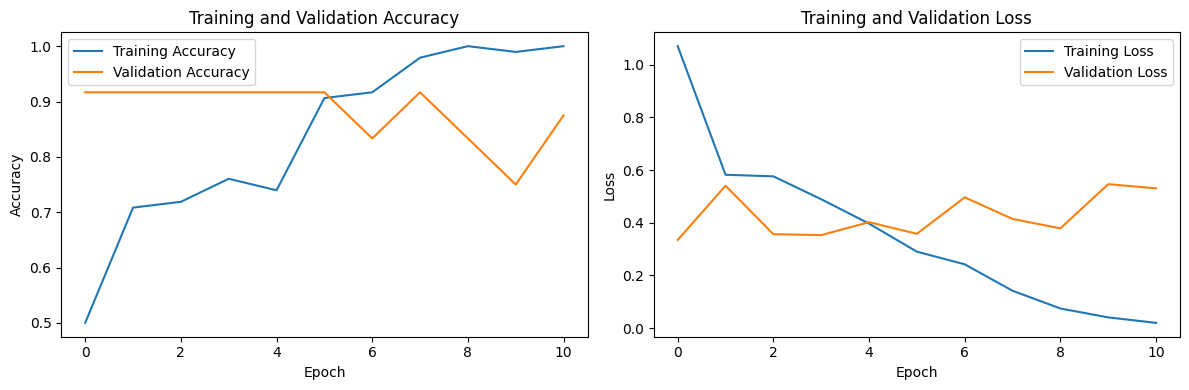

In [11]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Task 6: Evaluate the Model

In [12]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9167 - loss: 0.3345
Validation Loss: 0.3345
Validation Accuracy: 0.9167


### Task 7: Save and Load the Model

In [13]:
model.save('final_image_classifier.h5')

loaded_model = tf.keras.models.load_model('final_image_classifier.h5')

loaded_loss, loaded_accuracy = loaded_model.evaluate(val_ds)
print(f"Loaded Model Validation Loss: {loaded_loss:.4f}")
print(f"Loaded Model Validation Accuracy: {loaded_accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9167 - loss: 0.3345 
Loaded Model Validation Loss: 0.3345
Loaded Model Validation Accuracy: 0.9167


### Task 8: Predictions and Classification Report

In [14]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = loaded_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
              precision    recall  f1-score   support

        test       0.00      0.00      0.00         2
       train       0.92      1.00      0.96        22

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
